<h1 align="center"> Image Captioning (10 баллов) </h1>

В этом ноутбуке вы обучите сеть составлять подписи к изображениям.
![img](https://i.imgur.com/obITaMl.png)


#### План работы:

1. Использовать предобученную модель Inception v3 для преобразования изображений в векторы.

2. Добавить поверх неё LSTM.

3. Обучить модель на датасете [MSCOCO](http://cocodataset.org/#download).

### 1. Данные (0.5 балла)

In [1]:
# Скачайте датасет по ссылке https://drive.google.com/file/d/1j3Pey7vhGA5_OYrjos-gDwv5_gm7BPBO/view?usp=sharing

In [2]:
%%time
# Read Dataset
import numpy as np
import json

img_codes = np.load("data/image_codes.npy")
captions = json.load(open('data/captions_tokenized.json'))

CPU times: total: 2.2 s
Wall time: 8.01 s



Чтобы сэкономить ваше время, мы уже преобразовали все изображения из MSCOCO17 в векторы с помощью предобученной сети Inception_v3 из библиотеки [torchvision](https://github.com/pytorch/vision/blob/master/torchvision/models/inception.py).

Весь процесс занимает от одного дня на CPU до примерно 10 минут на трёх GPU Tesla M40. [Если хотите попробовать сделать это самостоятельно — пожалуйста.](https://gist.github.com/justheuristic/11fd01f9c12c0bf960499580d104130b).


In [3]:
print("Each image code is a 2048-unit vector [ shape: %s ]" % str(img_codes.shape))
print(img_codes[0,:10], end='\n\n')
print("For each image there are 5 reference captions, e.g.:\n")
print('\n'.join(captions[0]))

Each image code is a 2048-unit vector [ shape: (118287, 2048) ]
[0.3659946  0.2016555  0.9245725  0.57063824 0.547268   0.8275868
 0.3687277  0.12085301 0.0561931  0.49758485]

For each image there are 5 reference captions, e.g.:

people shopping in an open market for vegetables .
an open market full of people and piles of vegetables .
people are shopping at an open air produce market .
large piles of carrots and potatoes at a crowded outdoor market .
people shop for vegetables like carrots and potatoes at an open air market .


Как видно, все подписи уже токенизированы и приведены к нижнему регистру. Теперь нам нужно разделить их и добавить специальные токены, обозначающие начало и конец подписи.

In [4]:
#split descriptions into tokens
for img_i in range(len(captions)):
    for caption_i in range(len(captions[img_i])):
        sentence = captions[img_i][caption_i]
        captions[img_i][caption_i] = ["#START#"]+sentence.split(' ')+["#END#"]


Мы не хотим, чтобы сеть на каждом шаге предсказывала вероятности для миллиона слов, поэтому нужно немного сократить словарь.

Для этого посчитайте, **сколько раз встречается каждое слово** — так мы сможем решить, какие слова оставить в словаре.

In [5]:
# Build a Vocabulary
from collections import Counter
word_counts = Counter()

# Compute word frequencies for each word in captions. See code above for data structure
for img_captions in captions:
    for caption in img_captions:
        word_counts.update(caption)

word_counts

Counter({'a': 978125,
         '#START#': 591435,
         '#END#': 591435,
         '.': 444651,
         'on': 215537,
         'of': 203940,
         'the': 197668,
         'in': 183933,
         'with': 154705,
         'and': 140709,
         'is': 98138,
         'man': 72984,
         'to': 68106,
         'sitting': 52880,
         'an': 49848,
         'two': 48320,
         ',': 44448,
         'at': 42703,
         'standing': 42450,
         'people': 41895,
         'are': 41060,
         'next': 37196,
         'white': 36171,
         'woman': 33934,
         'street': 30253,
         'table': 30157,
         'holding': 27952,
         'that': 27920,
         'large': 24540,
         'it': 24528,
         'person': 24402,
         'some': 24314,
         'down': 23093,
         'top': 22262,
         'group': 21585,
         'up': 20964,
         'field': 20768,
         'small': 20074,
         'tennis': 19577,
         'near': 19558,
         'front': 19501,
         

In [6]:
vocab  = ['#UNK#', '#START#', '#END#', '#PAD#']
vocab += [k for k, v in word_counts.items() if v >= 5 if k not in vocab]
n_tokens = len(vocab)

assert 10000 <= n_tokens <= 10500

word_to_index = {w: i for i, w in enumerate(vocab)}

In [7]:
eos_ix = word_to_index['#END#']
unk_ix = word_to_index['#UNK#']
pad_ix = word_to_index['#PAD#']

def as_matrix(sequences, max_len=None):
    """ Convert a list of tokens into a matrix with padding """
    max_len = max_len or max(map(len,sequences))

    matrix = np.zeros((len(sequences), max_len), dtype='int32') + pad_ix
    for i,seq in enumerate(sequences):
        row_ix = [word_to_index.get(word, unk_ix) for word in seq[:max_len]]
        matrix[i, :len(row_ix)] = row_ix

    return matrix

In [8]:
#try it out on several descriptions of a random image
as_matrix(captions[1337])

array([[   1,   24,  262,  140,    6,  159,   14,   24,  858,  155,   12,
           2,    3,    3,    3,    3,    3,    3,    3],
       [   1,   24,  262,   53,   18,   24,  858,  155,    2,    3,    3,
           3,    3,    3,    3,    3,    3,    3,    3],
       [   1,   24,  262,   41,   18,  903,   35,  620,  155,    2,    3,
           3,    3,    3,    3,    3,    3,    3,    3],
       [   1,   45,  115,  262,   41,   53,   18,  620, 1525,   77,   12,
           2,    3,    3,    3,    3,    3,    3,    3],
       [   1,   24,  262,   53,   18,   24,  858,  123,   58,   45,  276,
        3641,   24, 3642,   35,   45, 1128,   12,    2]], dtype=int32)

### 2. Построение нейронной сети (1.5 балла)

Как уже упоминалось, мы создадим RNN-модель для генерации текста, которая будет зависеть от векторов, полученных из CNN-части сети.

![img](https://raw.githubusercontent.com/yunjey/pytorch-tutorial/master/tutorials/03-advanced/image_captioning/png/model.png)

Во время обучения мы будем использовать уже готовые вектора-признаков, а сеть Inception добавим на этапе инференса.


In [9]:
import torch, torch.nn as nn
import torch.nn.functional as F

In [10]:
class CaptionNet(nn.Module):
    def __init__(self, n_tokens=n_tokens, emb_size=128, lstm_units=256, cnn_feature_size=2048):
        """ A recurrent 'head' network for image captioning. See scheme above. """
        super(self.__class__, self).__init__()

        # a layer that converts conv features to
        self.cnn_to_h0 = nn.Linear(cnn_feature_size, lstm_units)
        self.cnn_to_c0 = nn.Linear(cnn_feature_size, lstm_units)

        # recurrent part, please create the layers as per scheme above.

        # create embedding for input words. Use the parameters (e.g. emb_size).
        self.emb = nn.Embedding(n_tokens, emb_size)

        # lstm: create a recurrent core of your network. Use either LSTMCell or just LSTM.
        # In the latter case (nn.LSTM), make sure batch_first=True
        self.lstm = nn.LSTM(emb_size, lstm_units, batch_first=True)

        # create logits: linear layer that takes lstm hidden state as input and computes one number per token
        self.logits = nn.Linear(lstm_units, n_tokens)

    def forward(self, image_vectors, captions_ix):
        """
        Apply the network in training mode.
        :param image_vectors: torch tensor containing inception vectors. shape: [batch, cnn_feature_size]
        :param captions_ix: torch tensor containing captions as matrix. shape: [batch, word_i].
            padded with pad_ix
        :returns: logits for next token at each tick, shape: [batch, word_i, n_tokens]
        """
        initial_cell = self.cnn_to_c0(image_vectors)
        initial_hid = self.cnn_to_h0(image_vectors)

        # compute embeddings for captions_ix
        captions_emb = self.emb(captions_ix)

        # apply recurrent layer to captions_emb.
        # 1. initialize lstm state with initial_* from above
        # 2. feed it with captions. Mind the dimension order in docstring
        # 3. compute logits for next token probabilities
        # Note: if you used nn.LSTM, you can just give it (initial_cell[None], initial_hid[None]) as second arg

        # lstm_out should be lstm hidden state sequence of shape [batch, caption_length, lstm_units]
        lstm_out, _ = self.lstm(captions_emb, (initial_hid[None], initial_cell[None]))

        # compute logits from lstm_out
        logits = self.logits(lstm_out)

        return logits

In [11]:
network = CaptionNet(n_tokens)

In [12]:
dummy_img_vec = torch.randn(len(captions[0]), 2048)
dummy_capt_ix = torch.tensor(as_matrix(captions[0]), dtype=torch.int64)

dummy_logits = network.forward(dummy_img_vec, dummy_capt_ix)

print('shape:', dummy_logits.shape)
assert dummy_logits.shape == (dummy_capt_ix.shape[0], dummy_capt_ix.shape[1], n_tokens)

shape: torch.Size([5, 16, 10403])


In [13]:
def compute_loss(network, image_vectors, captions_ix):
    """
    :param image_vectors: torch tensor containing inception vectors. shape: [batch, cnn_feature_size]
    :param captions_ix: torch tensor containing captions as matrix. shape: [batch, word_i].
        padded with pad_ix
    :returns: scalar crossentropy loss (neg llh) loss for next captions_ix given previous ones
    """

    # captions for input - all except last cuz we don't know next token for last one.
    captions_ix_inp = captions_ix[:, :-1].contiguous()
    captions_ix_next = captions_ix[:, 1:].contiguous()

    # apply the network, get predictions for captions_ix_next
    logits_for_next = network.forward(image_vectors, captions_ix_inp)


    # compute the loss function between logits_for_next and captions_ix_next
    # Use the mask, Luke: make sure that predicting next tokens after EOS do not contribute to loss
    # you can do that either by multiplying elementwise loss by (captions_ix_next != pad_ix)
    # or by using ignore_index in some losses.

    logits_flat = logits_for_next.reshape(-1, n_tokens)
    captions_flat = captions_ix_next.reshape(-1)

    loss = (F.cross_entropy(logits_flat, captions_flat, ignore_index=pad_ix)).unsqueeze(0)

    return loss

In [14]:
dummy_loss = compute_loss(network, dummy_img_vec, dummy_capt_ix)

assert dummy_loss.shape == torch.Size([1]), 'loss must be scalar'
assert dummy_loss.data.numpy() > 0, "did you forget the 'negative' part of negative log-likelihood"

dummy_loss.backward()

assert all(param.grad is not None for param in network.parameters()), \
        'loss should depend differentiably on all neural network weights'


Добавьте ~~adam~~ ваш любимы оптимизатор для обучения.

In [15]:
opt = torch.optim.AdamW(network.parameters(), lr=1e-3, weight_decay=0.01)

### 3. Обучение (5 баллов)

* Сначала реализуйте генератор батчей.
* Затем обучите сеть как обычно.

In [16]:
from sklearn.model_selection import train_test_split
captions = np.array(captions, dtype=object)
train_img_codes, val_img_codes, train_captions, val_captions = train_test_split(img_codes, captions,
                                                                                test_size=0.1,
                                                                                random_state=42)

In [17]:
from random import choice

def generate_batch(img_codes, captions, batch_size, max_caption_len=None):

    #sample random numbers for image/caption indicies
    random_image_ix = np.random.randint(0, len(img_codes), size=batch_size)

    #get images
    batch_images = img_codes[random_image_ix]

    #5-7 captions for each image
    captions_for_batch_images = captions[random_image_ix]

    #pick one from a set of captions for each image
    batch_captions = list(map(choice,captions_for_batch_images))

    #convert to matrix
    batch_captions_ix = as_matrix(batch_captions,max_len=max_caption_len)

    return torch.tensor(batch_images, dtype=torch.float32), torch.tensor(batch_captions_ix, dtype=torch.int64)


In [18]:
generate_batch(img_codes,captions,3)

(tensor([[0.2062, 0.0718, 1.0864,  ..., 0.1110, 0.0869, 0.0055],
         [0.5371, 0.2213, 0.7996,  ..., 0.1826, 0.7713, 0.1759],
         [0.2845, 0.3481, 0.7053,  ..., 0.2610, 0.9150, 0.1798]]),
 tensor([[   1,   88,  281,  921,   35,   24,   65,   58, 2116,    2,    3,    3,
             3,    3,    3,    3],
         [   1,   24,    0,   58, 1544, 1386,  884,  275,  115, 1149,   15,  576,
           999, 3890,   12,    2],
         [   1,   24,  115,   57,   78,   24,   79,   31,   24,  200,   12,    2,
             3,    3,    3,    3]]))

Обучайте модель на мини-батчах, как обычно. Периодически проверяйте качество на валидационном наборе.

#### **Советы**

* Если тренировочный лосс почти равен нулю или модель генерирует бессмысленный текст — проверьте, что вы предсказываете следующее слово, а не текущее или слово через два шага.

* Если модель создаёт плавные, но нерелевантные описания:

  * возможно, рекуррентная сеть не получает векторы изображения;

  * также это может быть следствием взрыва градиентов — попробуйте клиппинг или перезапуск обучения;

  * наконец, возможно, модель просто нужно обучить дольше.

* Кросс-энтропия — слабый показатель переобучения:

  * модель может переобучиться по валидационной кросс-энтропии, но при этом продолжать улучшать качество генерации;

  * используйте ручную оценку или автоматические метрики, такие как CIDEr или BLEU.

* Рекомендуется периодически проверять сеть с помощью блока “apply trained model” — можно остановить обучение, протестировать несколько примеров и продолжить.

* Типичные значения функции потерь: около 3–5, если усреднять по времени,
или масштабировать по длине при суммировании. Разумные подписи начинают появляться при лоссе 2.8–3.0.

In [19]:
batch_size = 50  # adjust me
n_epochs = 100  # adjust me
n_batches_per_epoch = 50  # adjust me
n_validation_batches = 5  # how many batches are used for validation after each epoch

In [20]:
from tqdm import tqdm

for epoch in range(n_epochs):

    train_loss=0
    network.train(True)
    for _ in tqdm(range(n_batches_per_epoch)):

        loss_t = compute_loss(network, *generate_batch(train_img_codes, train_captions, batch_size))


        # clear old gradients; do a backward pass to get new gradients; then train with opt
        opt.zero_grad()
        
        loss_t.backward()
        
        # (Опционально, но рекомендуется) Клиппинг градиента для предотвращения "взрыва"
        nn.utils.clip_grad_norm_(network.parameters(), 5.0)

        opt.step()

        train_loss += loss_t.item()

    train_loss /= n_batches_per_epoch

    val_loss=0
    network.train(False)
    for _ in range(n_validation_batches):
        loss_t = compute_loss(network, *generate_batch(val_img_codes, val_captions, batch_size))
        val_loss += loss_t.item()
    val_loss /= n_validation_batches

    print('\nEpoch: {}, train loss: {}, val loss: {}'.format(epoch, train_loss, val_loss))

print("Finished!")

100%|██████████████████████████████████████████████████████████████████████████████████| 50/50 [00:07<00:00,  6.40it/s]



Epoch: 0, train loss: 5.993596363067627, val loss: 4.861732387542725


100%|██████████████████████████████████████████████████████████████████████████████████| 50/50 [00:06<00:00,  7.81it/s]



Epoch: 1, train loss: 4.7572496795654295, val loss: 4.695858764648437


100%|██████████████████████████████████████████████████████████████████████████████████| 50/50 [00:06<00:00,  7.57it/s]


...


Epoch: 97, train loss: 2.6068854904174805, val loss: 2.670335817337036


100%|██████████████████████████████████████████████████████████████████████████████████| 50/50 [00:06<00:00,  7.60it/s]



Epoch: 98, train loss: 2.6699006175994873, val loss: 2.7305877685546873


100%|██████████████████████████████████████████████████████████████████████████████████| 50/50 [00:06<00:00,  7.88it/s]



Epoch: 99, train loss: 2.664801821708679, val loss: 2.716117095947266
Finished!


### 4. Применяем обученную модель (0.5 балла)

Теперь загрузим предобученнную Inceprion модель и посмотрим, на что способна наша модель.


In [21]:
from beheaded_inception3 import beheaded_inception_v3
inception = beheaded_inception_v3().train(False)

D:\Iterpretators\Python3.11\Lib\site-packages\torchvision\models\inception.py:43: FutureWarning: The default weight initialization of inception_v3 will be changed in future releases of torchvision. If you wish to keep the old behavior (which leads to long initialization times due to scipy/scipy#11299), please set init_weights=True.
  warnings.warn(


#### **Генерируем подписи**

Функция ниже генерирует подписи, выбирая слова на основе вероятностей, предсказанных моделью.

Реализация здесь простая, но неэффективная (её сложность квадратична по числу шагов LSTM).

In [22]:
def generate_caption(image, caption_prefix=("#START#",),
                     t=1, sample=True, max_len=100):
    assert isinstance(image, np.ndarray) and np.max(image) <= 1\
           and np.min(image) >=0 and image.shape[-1] == 3

    with torch.no_grad():
        image = torch.tensor(image.transpose([2, 0, 1]), dtype=torch.float32)

        vectors_8x8, vectors_neck, logits = inception(image[None])
        caption_prefix = list(caption_prefix)

        for _ in range(max_len):

            prefix_ix = as_matrix([caption_prefix])
            prefix_ix = torch.tensor(prefix_ix, dtype=torch.int64)
            next_word_logits = network.forward(vectors_neck, prefix_ix)[0, -1]
            next_word_probs = F.softmax(next_word_logits, dim=-1).data.numpy()

            assert len(next_word_probs.shape) ==1, 'probs must be one-dimensional'
            next_word_probs = next_word_probs ** t / np.sum(next_word_probs ** t) # apply temperature

            if sample:
                next_word = np.random.choice(vocab, p=next_word_probs)
            else:
                next_word = vocab[np.argmax(next_word_probs)]

            caption_prefix.append(next_word)

            if next_word == "#END#":
                break

    return caption_prefix

In [23]:
from matplotlib import pyplot as plt
#from scipy.misc import imresize
from PIL import Image
%matplotlib inline

# sample image
# !wget https://pixel.nymag.com/imgs/daily/selectall/2018/02/12/12-tony-hawk.w710.h473.jpg -O data/img.jpg
# img = plt.imread('data/img.jpg')
# img = imresize(img, (299, 299)).astype('float32') / 255.
img_path = 'data/img.jpg'
img = Image.open(img_path)

target_size = (299, 299) 
img = img.resize(target_size)
img = np.array(img).astype('float32') / 255.

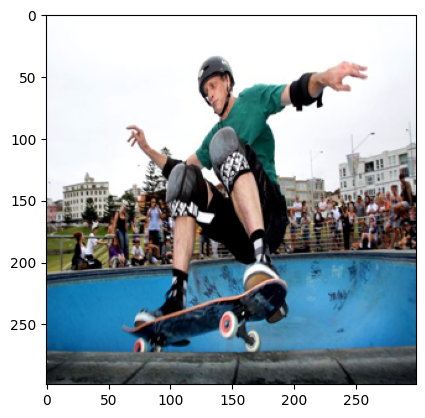

In [24]:
plt.imshow(img)

In [25]:
for i in range(10):
    print(' '.join(generate_caption(img, t=5.)[1:-1]))

a man riding a skateboard down a ramp .
a man riding a skateboard down a street .
a man riding a skateboard down a ramp .
a man riding a skateboard on a rail .
a man riding a skateboard down a ramp .
a man on a skateboard in a skate park .
a man riding a skateboard down a ramp .
a man riding a skateboard down a ramp .
a man riding a skateboard on a ramp .
a man riding a skateboard down a ramp .


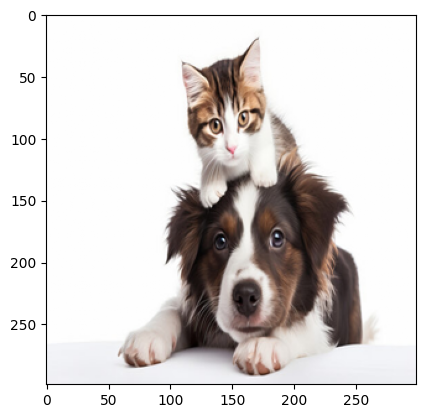

a dog is sitting on a couch with a dog .
a dog is sitting on a chair in a room .
a dog is sitting on a couch with a dog .
a dog is sitting on a couch with a dog .
a dog is sitting on a chair with a dog .
a dog is sitting on a couch with a dog .
a dog is sitting on a couch with a dog .
a dog is sitting on a couch with a dog .
a dog is sitting on a couch with a dog .
a dog is sitting on a couch with a dog .


In [26]:
# !wget http://ccanimalclinic.com/wp-content/uploads/2017/07/Cat-and-dog-1.jpg -O data/img.jpg - broken link
img_path = 'data/img1.jpg'
img = Image.open(img_path)

target_size = (299, 299) 
img = img.resize(target_size)
img = np.array(img).astype('float32') / 255.

plt.imshow(img)
plt.show()

for i in range(10):
    print(' '.join(generate_caption(img, t=5.)[1:-1]))

### 5. Demo (2.5 балла)
##### **Найдите как минимум 10 изображений для теста.**

* Серьёзно, это часть задания — подготовьте хотя бы 10 картинок для генерации подписей.

* Сначала проверьте работу модели на простых изображениях, прежде чем переходить к более сложным.

* В вашем наборе должны быть примеры как удачных, так и неудачных подписей — проявите креативность :)

* Используйте фотографии, а не анимацию, 3D или рисунки — иначе придётся переобучать CNN на аниме.

* Обратите внимание на соотношение сторон изображений.

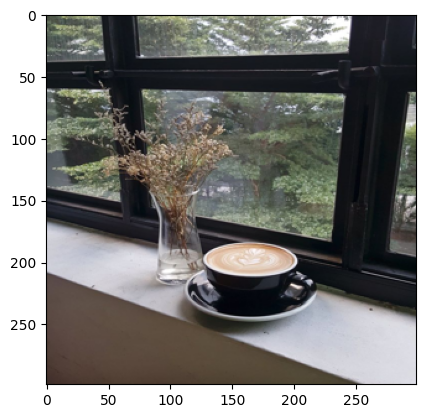

a table with a table and a table with a table .
a small dog is sitting on a table .
a small dog sitting in a small table with a glass of wine .
a brown and white photo of a vase with a table .
a small dog sitting on top of a table .
a black and white photo of a vase with a table .
a small dog sitting on a table next to a table .
a table with a table and a table with a table and a table .
a dog is sitting on a table with a glass of wine .
a table with a table and a table with a table .


In [27]:
img_path = 'data/demo1.jpg'
img = Image.open(img_path)

target_size = (299, 299) 
img = img.resize(target_size)
img = np.array(img).astype('float32') / 255.

plt.imshow(img)
plt.show()

for i in range(10):
    print(' '.join(generate_caption(img, t=5.)[1:-1]))

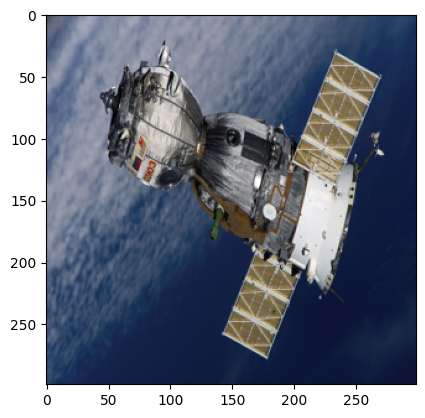

a large airplane flying over a body of water .
a large airplane flying through the air .
a large airplane flying in the air on a cloudy day .
a large airplane flying in the air with a kite in the background .
a large airplane flying through the air above a cloudy sky .
a large airplane flying in the sky .
a large white airplane flying through a cloudy sky .
a large airplane flying in the air .
a large airplane flying over a bridge .
a large airplane flying over a body of water .


In [28]:
img_path = 'data/demo2.jpg'
img = Image.open(img_path)

target_size = (299, 299) 
img = img.resize(target_size)
img = np.array(img).astype('float32') / 255.

plt.imshow(img)
plt.show()

for i in range(10):
    print(' '.join(generate_caption(img, t=5.)[1:-1]))

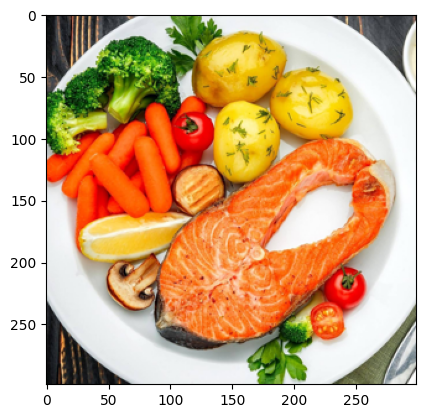

a plate of food with a salad on it .
a plate of food with a fork and a fork on it .
a plate of food with a sandwich and a bowl of broccoli .
a plate of food with a sandwich and a salad
a plate of food with a salad and a fork .
a plate of food with a salad and a fork .
a plate with a sandwich and a salad on it .
a plate of food with a salad and a fork .
a plate of food with a sandwich and a fork on it .
a plate of food with a salad and a fork .


In [29]:
img_path = 'data/demo3.jpg'
img = Image.open(img_path)

target_size = (299, 299) 
img = img.resize(target_size)
img = np.array(img).astype('float32') / 255.

plt.imshow(img)
plt.show()

for i in range(10):
    print(' '.join(generate_caption(img, t=5.)[1:-1]))

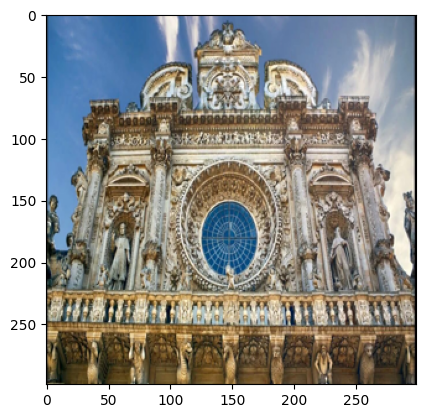

a large clock tower with a clock on it .
a large clock tower with a clock on it .
a large clock tower with a clock on it .
a large clock tower in a city .
a large clock tower with a clock on it .
a large clock tower with a clock on it .
a large clock tower with a clock on it .
a large clock tower with a clock on top of it .
a large clock tower with a clock on it .
a large clock tower with a clock on top of it .


In [30]:
img_path = 'data/demo4.jpg'
img = Image.open(img_path)

target_size = (299, 299) 
img = img.resize(target_size)
img = np.array(img).astype('float32') / 255.

plt.imshow(img)
plt.show()

for i in range(10):
    print(' '.join(generate_caption(img, t=5.)[1:-1]))

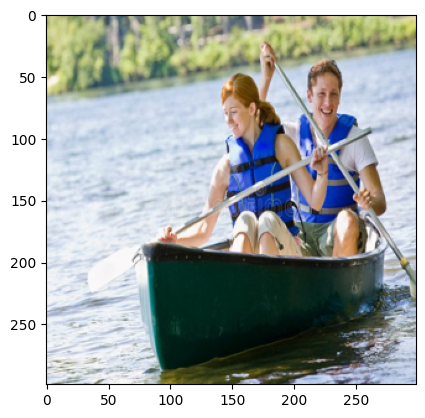

a man is sitting on a boat in the water .
a man in a boat with a dog on it .
a man is riding a small dog in a boat .
a man in a boat with a dog in the background .
a man in a boat and a boat on a boat .
a man is riding a surfboard in the water .
a man in a boat in a boat .
a man in a boat on a boat .
a man is sitting on a surfboard in the water .
a man in a boat on a boat in a body of water .


In [31]:
img_path = 'data/demo5.jpg'
img = Image.open(img_path)

target_size = (299, 299) 
img = img.resize(target_size)
img = np.array(img).astype('float32') / 255.

plt.imshow(img)
plt.show()

for i in range(10):
    print(' '.join(generate_caption(img, t=5.)[1:-1]))

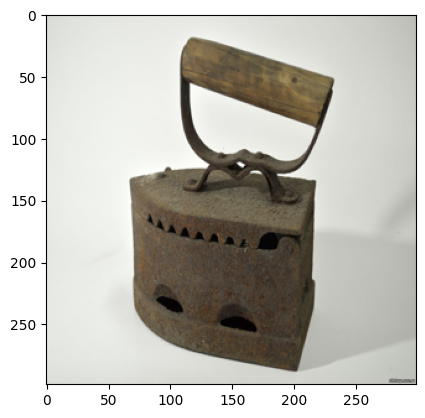

a dog is sitting on a couch with a remote .
a dog is sitting on a couch with a dog .
a dog is sitting on a couch next to a black and white dog .
a dog is sitting on a couch with a frisbee .
a dog is sitting on a couch next to a cat .
a dog is sitting on a couch with a remote control .
a dog is sitting on a couch in a room .
a dog is sitting on a couch in a room .
a dog is sitting on a couch in a room .
a dog is sitting on a couch with a dog .


In [32]:
img_path = 'data/demo6.jpg'
img = Image.open(img_path)

target_size = (299, 299) 
img = img.resize(target_size)
img = np.array(img).astype('float32') / 255.

plt.imshow(img)
plt.show()

for i in range(10):
    print(' '.join(generate_caption(img, t=5.)[1:-1]))

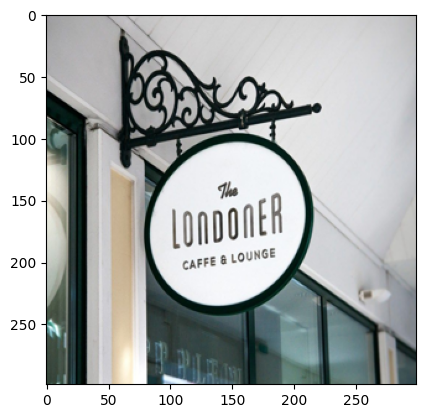

a close up of a sign on a pole
a sign that is on a pole in front of a building .
a sign that is in front of a building .
a sign that is on a pole in a city .
a sign that is on a pole in front of a building .
a sign that is on the side of a building .
a sign that is on a pole in front of a building .
a sign that is on a pole in front of a building .
a sign that is on a pole in the background .
a close up of a sign that is on a pole


In [33]:
img_path = 'data/demo7.jpg'
img = Image.open(img_path)

target_size = (299, 299) 
img = img.resize(target_size)
img = np.array(img).astype('float32') / 255.

plt.imshow(img)
plt.show()

for i in range(10):
    print(' '.join(generate_caption(img, t=5.)[1:-1]))

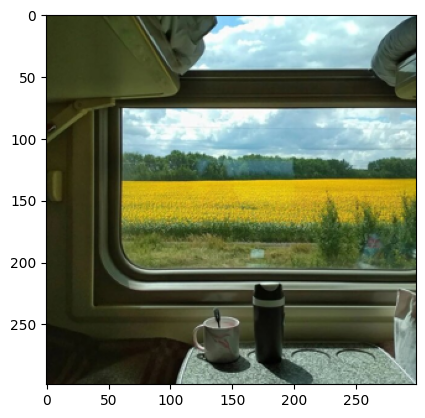

a close up of a cat sitting on a bench
a close up of a cat on a table
a man is sitting on a bench next to a window .
a man sitting on a table next to a window .
a close up of a cat looking at a window
a small dog is sitting on a chair in a window .
a man sitting on a table with a dog .
a man in a white shirt and a black and white shirt
a man is sitting on a bench in a window .
a man is sitting on a bench next to a window .


In [34]:
img_path = 'data/demo8.jpg'
img = Image.open(img_path)

target_size = (299, 299) 
img = img.resize(target_size)
img = np.array(img).astype('float32') / 255.

plt.imshow(img)
plt.show()

for i in range(10):
    print(' '.join(generate_caption(img, t=5.)[1:-1]))

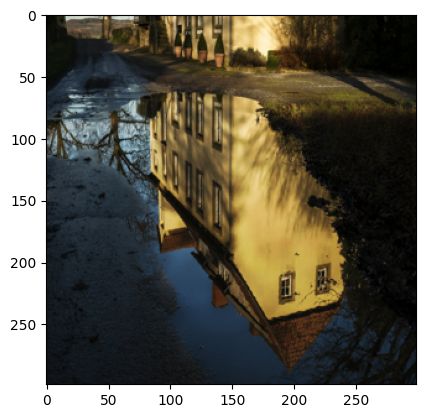

a boat is in the water with a body of water .
a boat is in the water near a river .
a boat in the water with a bridge in the background .
a boat is in the water with a bridge in the background .
a boat is on the water near a bridge .
a small boat with a bridge in the water .
a small boat is in the water near a river .
a boat is on a river in a river .
a small boat on a river with a bridge in the background .
a boat is on a river with a bridge in the background .


In [35]:
img_path = 'data/demo9.jpg'
img = Image.open(img_path)

target_size = (299, 299) 
img = img.resize(target_size)
img = np.array(img).astype('float32') / 255.

plt.imshow(img)
plt.show()

for i in range(10):
    print(' '.join(generate_caption(img, t=5.)[1:-1]))

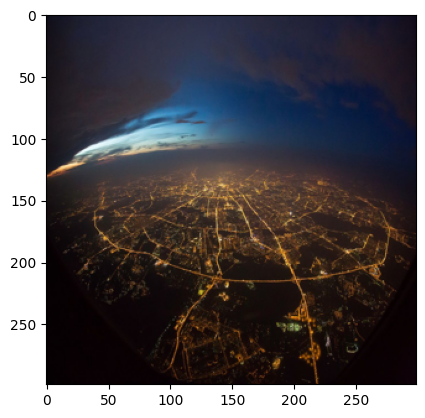

a man in a blue shirt is standing in front of a building .
a close up of a person on a bed
a man is standing in front of a building .
a man in a black jacket is standing in front of a building .
a man in a blue shirt is standing in a room .
a person is standing in a chair in front of a building .
a person is standing in a grassy area .
a man is standing in a field of grass .
a man is standing in a large field of grass .
a person is standing in a large grassy area .


In [36]:
img_path = 'data/demo10.jpg'
img = Image.open(img_path)

target_size = (299, 299) 
img = img.resize(target_size)
img = np.array(img).astype('float32') / 255.

plt.imshow(img)
plt.show()

for i in range(10):
    print(' '.join(generate_caption(img, t=5.)[1:-1]))

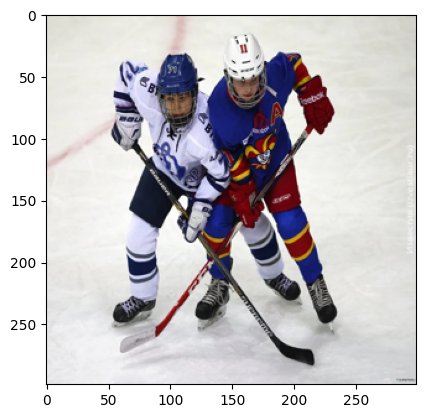

a group of people in a snow covered ski slope .
a group of people on skis in a snow covered slope .
a group of people standing on top of a snow covered slope .
a group of people standing on top of a snow covered slope .
a man is holding a baseball bat .
a group of people standing on a snowy surface .
a group of people standing in a snow covered slope .
a group of people in a snow covered ski .
a group of people standing on top of a snow covered slope .
a group of people on skis in a snow covered slope .


In [37]:
img_path = 'data/demo11.jpg'
img = Image.open(img_path)

target_size = (299, 299) 
img = img.resize(target_size)
img = np.array(img).astype('float32') / 255.

plt.imshow(img)
plt.show()

for i in range(10):
    print(' '.join(generate_caption(img, t=5.)[1:-1]))

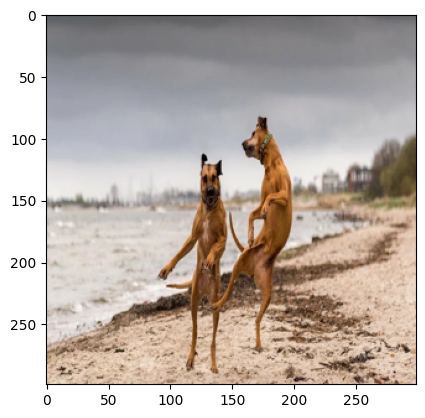

a man riding a dog on a beach next to a frisbee .
a dog is riding a dog on a beach .
a man riding a dog on a beach .
a dog is sitting on a surfboard in the ocean .
a dog is riding a dog on a beach .
a dog is sitting on a surfboard in the ocean .
a dog is standing on a beach with a dog .
a person on a surfboard in the ocean .
a man riding a dog on a beach with a dog .
a dog is on a surfboard in the water .


In [38]:
img_path = 'data/demo12.jpg'
img = Image.open(img_path)

target_size = (299, 299) 
img = img.resize(target_size)
img = np.array(img).astype('float32') / 255.

plt.imshow(img)
plt.show()

for i in range(10):
    print(' '.join(generate_caption(img, t=5.)[1:-1]))

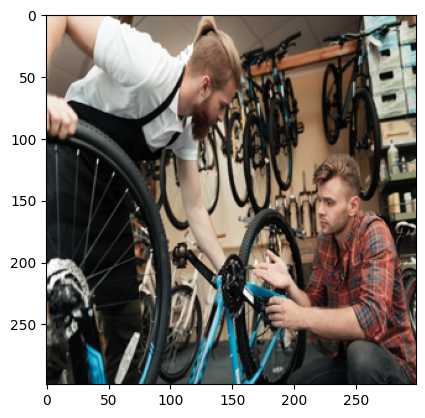

a woman is sitting on a motorcycle on a bike .
a man is sitting on a motorcycle with a dog .
a woman is holding a red and white dog .
a man holding a dog in a red shirt .
a man is riding a motorcycle on a street .
a woman in a red jacket is holding a red umbrella .
a man is holding a red motorcycle in a parking lot .
a man is riding a motorcycle on a sidewalk .
a man on a bike with a dog in a suit .
a man holding a dog on a motorcycle .


In [39]:
img_path = 'data/demo13.jpg'
img = Image.open(img_path)

target_size = (299, 299) 
img = img.resize(target_size)
img = np.array(img).astype('float32') / 255.

plt.imshow(img)
plt.show()

for i in range(10):
    print(' '.join(generate_caption(img, t=5.)[1:-1]))


![img](https://cs7.pikabu.ru/images/big_size_comm_an/2018-09_3/1536865148163644198.gif)

> Примечание: Это задание адаптировано по материалам курса "Deep Learning" (Skoltech).


In [55]:
import requests

url = "https://img.freepik.com/premium-photo/young-guy-came-workshop-repair-his-bicycle_85574-14868.jpg"
local_path = "data/demo13.jpg"

response = requests.get(url)

import os
os.makedirs("data", exist_ok=True)

with open(local_path, 'wb') as f:
    f.write(response.content)

print(f"Изображение сохранено как {local_path}")

Изображение сохранено как data/demo13.jpg


Обученная модель демонстрирует стабильную способность генерировать грамматически правильные подписи к изображениям. После 100 эпох обучения с снижением лосса с 5.99 до 2.66 модель научилась распознавать основные объекты и составлять осмысленные описания. Однако качество генерации сильно зависит от сложности сцены - с простыми изображениями модель справляется лучше.

Проведенная демонстрация на 13 изображениях показывает, что модель успешно освоила базовый уровень распознавания объектов, но ей не хватает глубины для реального понимания сцены. Она отлично справляется с идентификацией распространенных объектов, часто встречающихся в датасетах сцен. Однако модель сразу "ломается" или "галлюцинирует", добавляя несуществующие объекты, когда требуется понять контекст или сложное действие. Она видит "человека и велосипед", но не понимает, что это "ремонт в мастерской" (demo13); и она полностью игнорирует специфичные предметы, такие как старинный утюг (demo6), пытаясь описать их более общими словами. 